In [4]:
import numpy as np
from matplotlib import pyplot as plt
import json
from pathlib import Path
import pandas as pd
import pickle

from analysis import find_peaks

In [ ]:
pickle_path = Path("/home/elyons/Documents/dev/SensorFusion/TDOA_simulator/output/model_calibration.pkl")
model = pickle.load(open(pickle_path, "rb"))

# find_peaks(model.sensor_array[0])

# plt.plot(model.sensor_array[0].timestamp, model.sensor_array[0].data)


1000

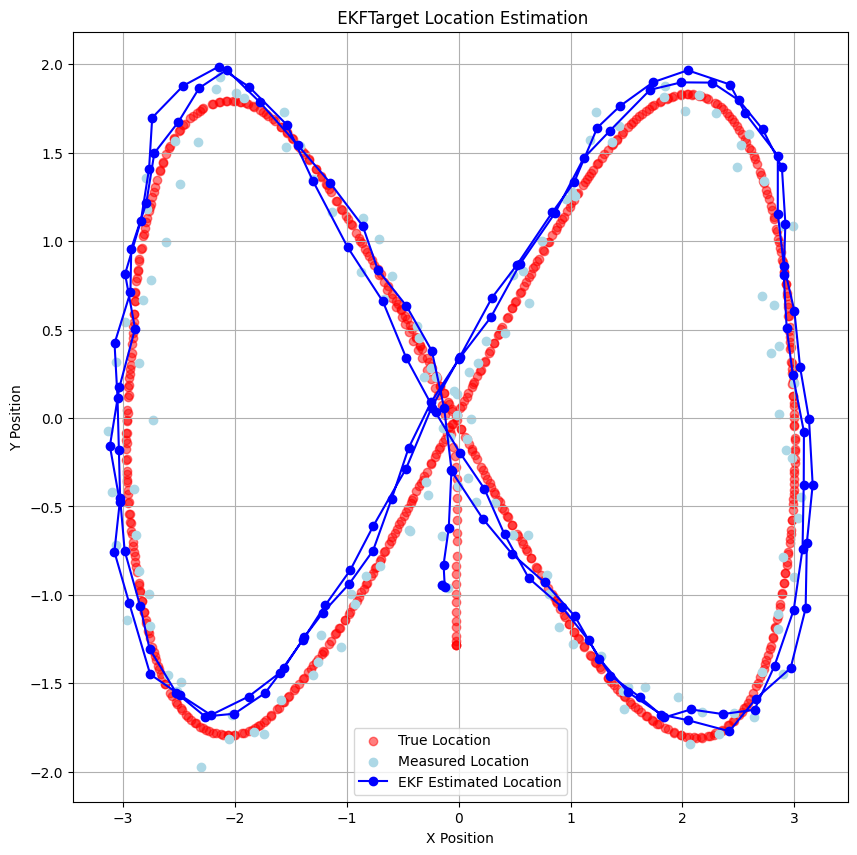

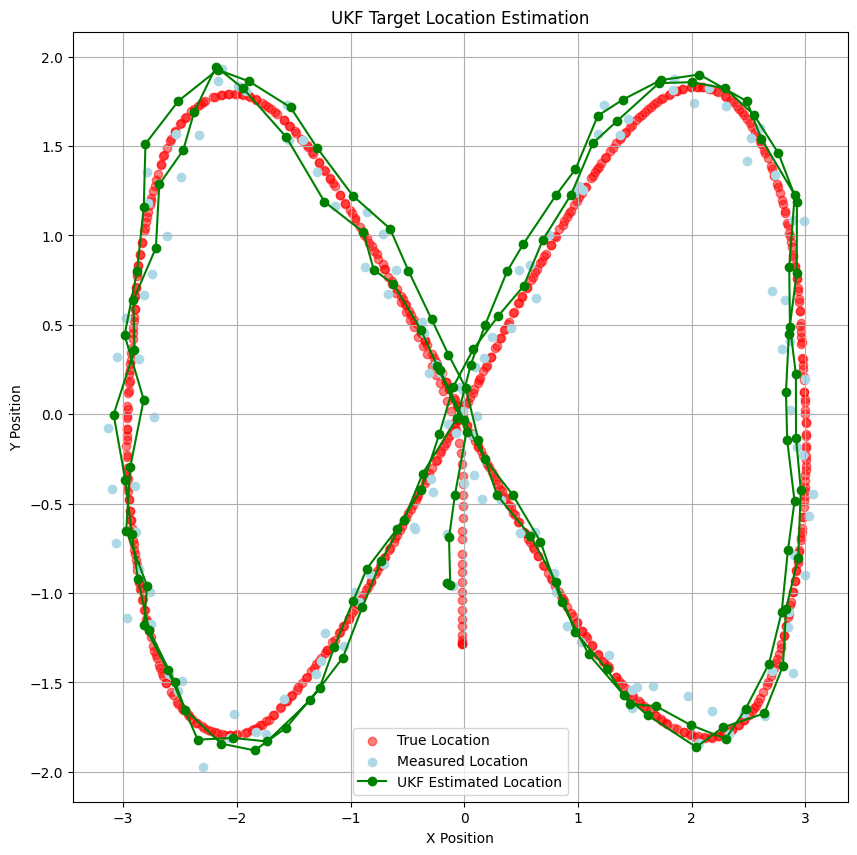

In [ ]:
results_path = Path("/home/elyons/Documents/dev/SensorFusion/TDOA_simulator/output/simulation_report.json")
results = json.loads(results_path.read_text())

true_locations = results['target_location']
measured_locations = results['target_location_measured']
ekf_locations = results['target_location_ekf']
ukf_locations = results['target_location_ukf']
singer_ekf_locations = results['target_location_singer_ekf']


true_loc = []
for entry in true_locations:
    true_loc.append(np.array([entry['x'], entry['y']]))
true_loc = np.array(true_loc)

m_loc = []
m_loc_timstamps = []
for entry in measured_locations:
    m_loc.append(np.array([entry['x'], entry['y']]))
    m_loc_timstamps.append(entry['timestamp'])
m_loc = np.array(m_loc)
m_loc_timstamps = np.array(m_loc_timstamps)

ekf_loc = []
ekf_loc_timstamps = []
for entry in ekf_locations:
    ekf_loc.append(np.array([entry['x'], entry['y']]))
    ekf_loc_timstamps.append(entry['timestamp'])
ekf_loc = np.array(ekf_loc)
ekf_loc_timstamps = np.array(ekf_loc_timstamps)

ukf_loc = []
ukf_loc_timstamps = []
for entry in ukf_locations:
    ukf_loc.append(np.array([entry['x'], entry['y']]))
    ukf_loc_timstamps.append(entry['timestamp'])
ukf_loc = np.array(ukf_loc)
ukf_loc_timstamps = np.array(ukf_loc_timstamps)

singer_ekf_loc = []
singer_ekf_loc_timstamps = []
for entry in singer_ekf_locations:
    singer_ekf_loc.append(np.array([entry['x'], entry['y']]))
    singer_ekf_loc_timstamps.append(entry['timestamp'])
singer_ekf_loc = np.array(singer_ekf_loc)
singer_ekf_loc_timstamps = np.array(singer_ekf_loc_timstamps)


# CTVR EKF
plt.figure(figsize=(10, 10))
plt.scatter(true_loc[:, 0], true_loc[:, 1], alpha=0.5, label="True Location", color='red', marker='o')
plt.scatter(m_loc[:, 0], m_loc[:, 1], label="Measured Location", marker='o', color='lightblue')
plt.plot(ekf_loc[:, 0], ekf_loc[:, 1], 'o-', label="EKF Estimated Location", color='blue')

plt.title(" EKFTarget Location Estimation")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid()

# CTVRUKF
plt.figure(figsize=(10, 10))
plt.scatter(true_loc[:, 0], true_loc[:, 1], alpha=0.5, label="True Location", color='red', marker='o')
plt.scatter(m_loc[:, 0], m_loc[:, 1], label="Measured Location", marker='o', color='lightblue')
plt.plot(ukf_loc[:, 0], ukf_loc[:, 1], 'o-', label="UKF Estimated Location", color='green')

plt.title("UKF Target Location Estimation")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid()


# Singer EKF
plt.figure(figsize=(10, 10))
plt.scatter(true_loc[:, 0], true_loc[:, 1], alpha=0.5, label="True Location", color='red', marker='o')
plt.scatter(m_loc[:, 0], m_loc[:, 1], label="Measured Location", marker='o', color='lightblue')
plt.plot(singer_ekf_loc[:, 0], singer_ekf_loc[:, 1], 'o-', label="Singer EKF Estimated Location", color='purple')
plt.title("Singer EKF Target Location Estimation")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid()